In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%cd "/content/drive/MyDrive/Master's Thesis v0.4/TM Project/"

/content/drive/MyDrive/Master's Thesis v0.4/TM Project


In [ ]:
%load_ext autoreload
%autoreload 2

In [ ]:
# !pip install scikit-optimize

In [ ]:
# from skopt import gp_minimize
# from skopt import space

In [ ]:
import devices
import models
import samplers
import trainers
import utils

import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

from scipy.io import loadmat

In [ ]:

memory_type = torch.device('cuda')
dtype = torch.float32
num_modes = 1
study = 'scalar'

In [ ]:
weights = [10, 1/2, 1, 1, 1, 1]
m = 3

# device 1

In [ ]:
# parameters
lambd = 1

# wave number and normalized spacing
k_0 = 2 * np.pi / lambd

# device 1

# spacing
dx = (0.0952/1.55) * k_0
dy =  (0.05/1.55) * k_0

# simulation lengths

core_length_x = ((2/1.55) * lambd) * k_0 # W
core_length_y = ((1.1/1.55) * lambd) * k_0 # H

substrate_length_x = ((3.0/1.55) * lambd) * k_0 # Xs
substrate_length_y = ((5.025/1.55) * lambd) * k_0 # Ys

rib_length = ((0.2/1.55) * lambd) * k_0 # D

cladding_length_y = ((0.525/1.55) * lambd) * k_0 # Yc

# refractive indices
n_core = 3.44
n_substrate = 3.34
n_cladding = 1

In [ ]:
reference_device = devices.RibWaveguide(n_substrate, n_core, n_cladding, lambd, [substrate_length_x, core_length_x, substrate_length_x], [substrate_length_y, rib_length, core_length_y, cladding_length_y], study)

In [ ]:
xy = samplers.uniform_grid_2d(reference_device, dx, dy, dtype, memory_type)
xy = xy.cpu()
boudndary_pts, boundary_vals = reference_device.get_boundaries(xy.detach().clone(), dx, dy, dtype,  memory_type)
discontinuities = reference_device.get_discontinuities(xy.detach().clone(), dx, dy)

<ipython-input-12-8c52820d3a78>:5: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(boudndary_pts[:, 0], boudndary_pts[:, 1], marker='x', s=4, c='black', cmap=cm);
<ipython-input-12-8c52820d3a78>:10: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(discontinuity[:, 0].detach(), discontinuity[:, 1].detach(), s=1/2, marker='x', c='orange', cmap=cm);


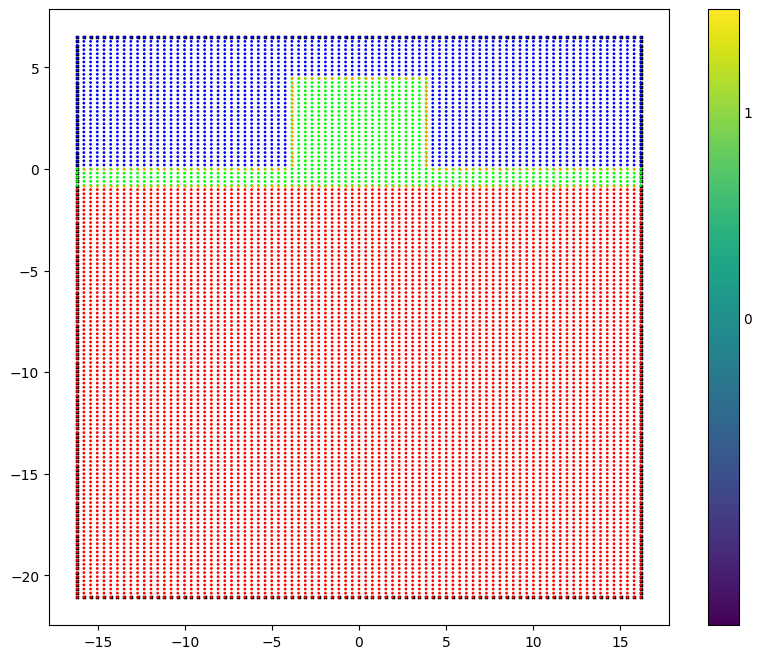

In [ ]:
plt.figure(figsize=(10, 8))

from_list = matplotlib.colors.LinearSegmentedColormap.from_list
cm = from_list(None, [(1, 0, 0), (0, 1, 0), (0, 0, 1)], 3)
plt.scatter(boudndary_pts[:, 0], boudndary_pts[:, 1], marker='x', s=4, c='black', cmap=cm);

plt.scatter(xy[:, 0], xy[:, 1], s=1, c=reference_device.regions(xy, format='torch'), cmap=cm);

for discontinuity in discontinuities:
  plt.scatter(discontinuity[:, 0].detach(), discontinuity[:, 1].detach(), s=1/2, marker='x', c='orange', cmap=cm);

# len_rib = guide.lengths_y[1]
# len_rib = ((guide.lengths_y[1])//dy)*dy

# plt.axhline(y=-len_rib, color='black', linestyle='dashed')
plt.clim(-1.5, 1.5)
cb = plt.colorbar(ticks=[0, 1])
cb.ax.tick_params(length=0)

In [ ]:
torch.manual_seed(42)
# base_model = models.discontinuity_capturing_network(2, 256, num_modes, 1, 'RBF')
base_model = models.discontinuity_capturing_network(2, 512, num_modes, 1, 'DRBF')
optimizer = torch.optim.Adamax(base_model.parameters(), lr=1e-2)
# optimizer = torch.optim.LBFGS(base_model.parameters(),
#                               lr=float(5e-1),
#                               max_iter=5000,
#                               max_eval=5000,
#                               history_size=300,
#                               line_search_fn="strong_wolfe",
#                               tolerance_change=10.0 * np.finfo(float).eps)
# scheduler = torch.optim.lr_scheduler.MultiStepLR(optimzer, milestones=[1000, 2000, 3000], gamma=0.2)
scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=[5000], gamma=1e-2)
print('number of trainable parameters', sum([p.numel() for p in base_model.parameters() if p.requires_grad]))

number of trainable parameters 3073


In [ ]:
device = devices.RibWaveguideWithPINNs(n_substrate, n_core, n_cladding, lambd, [substrate_length_x, core_length_x, substrate_length_x], [substrate_length_y, rib_length, core_length_y, cladding_length_y], study, base_model, True)

In [ ]:
reference_device_fd = devices.RibWaveguideWithFD(n_substrate, n_core, n_cladding, lambd, [substrate_length_x, core_length_x, substrate_length_x], [substrate_length_y, rib_length, core_length_y, cladding_length_y], study, dx, dy)

In [ ]:
base_model.to(memory_type)
dummy_optim = torch.optim.Adamax(base_model.parameters(), lr=1e-2)
xy_dummy = torch.rand(1000, 3).to(memory_type)*10-5
example_fun = torch.exp(-(xy_dummy[:, 0]**2+xy_dummy[:, 1]**2)/10)*5
example_fun = example_fun.unsqueeze(1)
for i in range(1000):
  optimizer.zero_grad()
  u = base_model(xy_dummy)
  loss = torch.mean((u-example_fun)**2)
  base_model.zero_grad()
  loss.backward()
  optimizer.step()
dummy_optim.zero_grad()
print(loss.item())

2.632291398185771e-05


In [ ]:
train_agent = trainers.Trainer2D(dtype, device, reference_device_fd, memory_type, samplers.uniform_grid_2d, optimizer, scheduler, dx=dx, dy=dy, num_samples=None, n_lower=None, n_upper=None)

num samples 11645


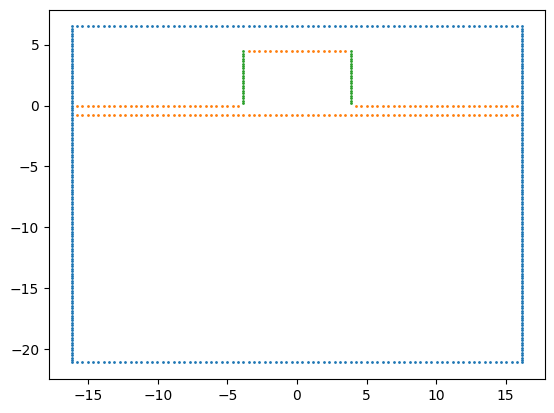

iteration 1 loss1 is 0.37554, loss2 is 1.34923, loss3 is -11.16217, loss4 is 0.0, loss5 is 0.1885, loss6 is 0.30803, total loss 0.8720736503601074
3.3409828786539726


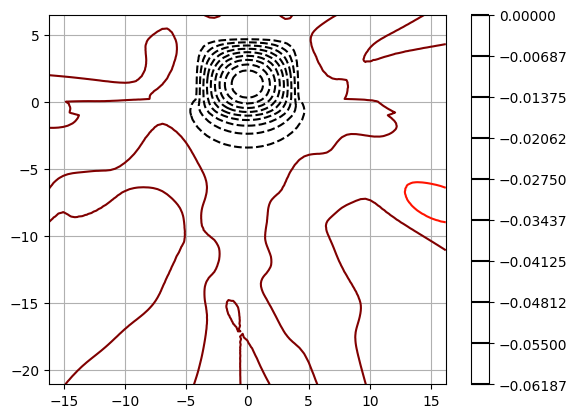

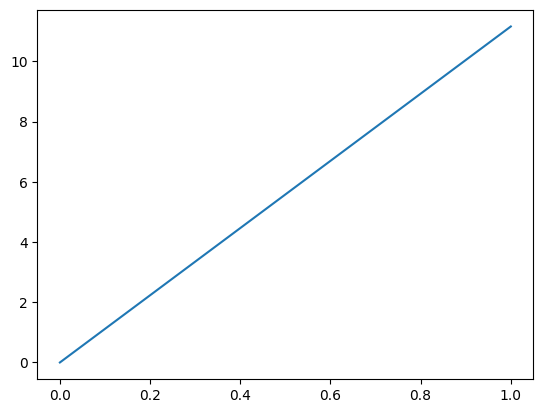

iteration 1001 loss1 is 0.03864, loss2 is 0.03118, loss3 is -0.00125, loss4 is 0.0, loss5 is 0.00471, loss6 is 0.05866, total loss 0.10200593620538712
3.3849767937139443


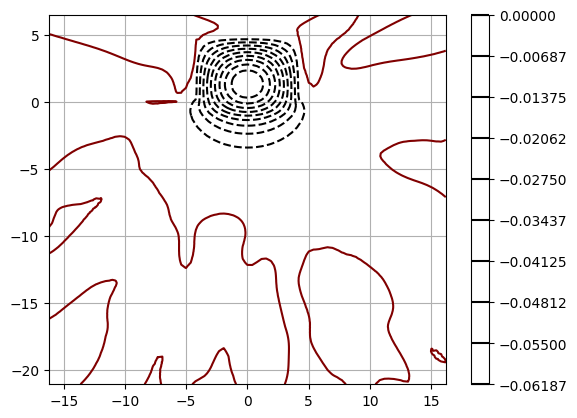

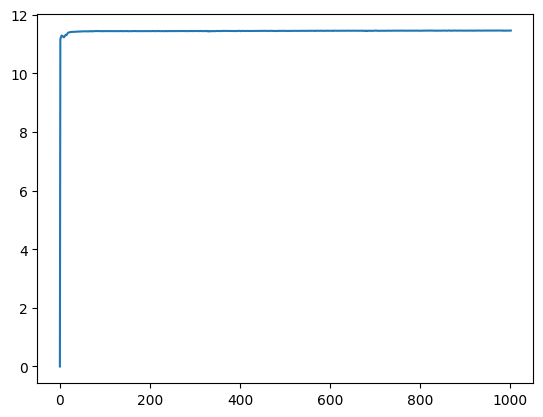

iteration 2001 loss1 is 0.03072, loss2 is 0.02586, loss3 is -0.00042, loss4 is 0.0, loss5 is 0.00336, loss6 is 0.06857, total loss 0.1026405617594719
3.386927262765494


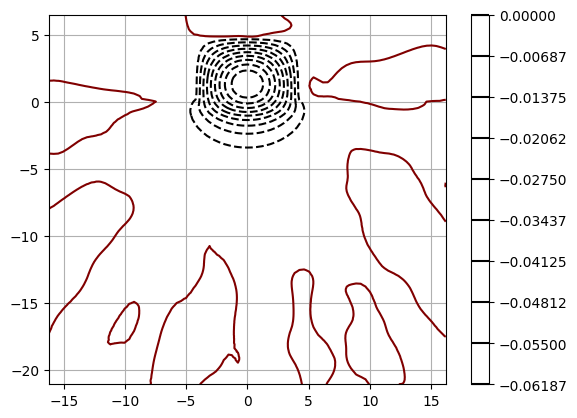

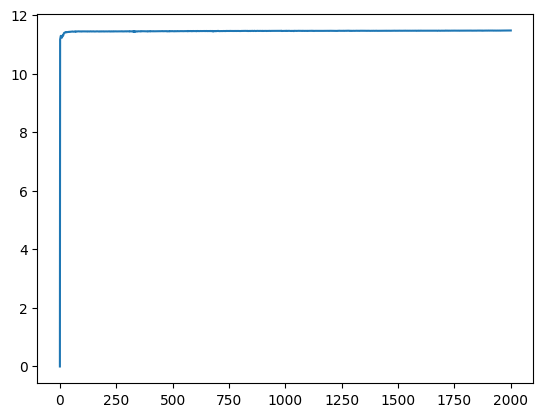

iteration 3001 loss1 is 0.02484, loss2 is 0.01971, loss3 is -0.00176, loss4 is 0.0, loss5 is 0.00317, loss6 is 0.06074, total loss 0.08874691277742386
3.3884340582076096


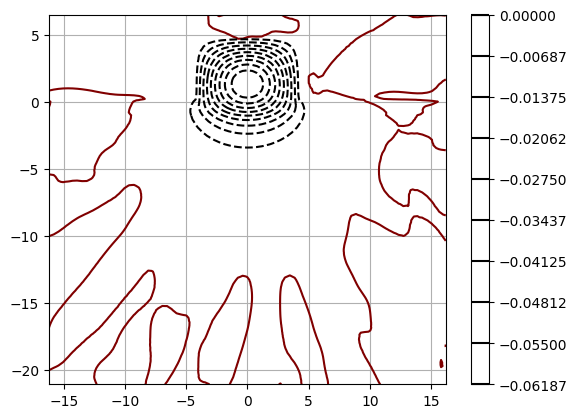

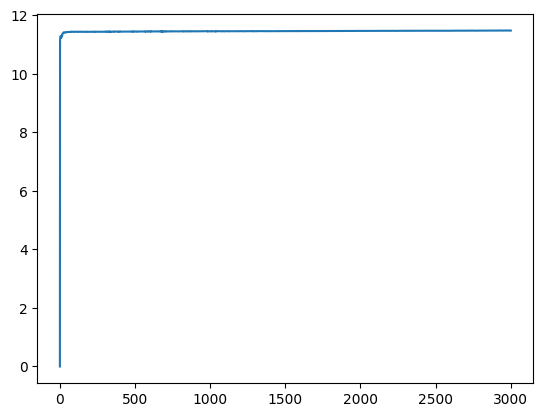

iteration 4001 loss1 is 0.01978, loss2 is 0.01355, loss3 is -0.00139, loss4 is 0.0, loss5 is 0.00215, loss6 is 0.07032, total loss 0.0922456607222557
3.3895661419082965


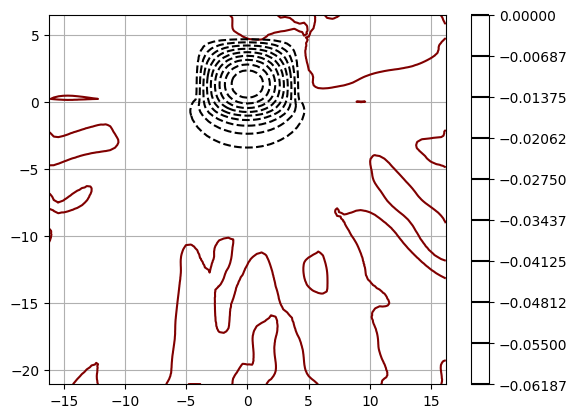

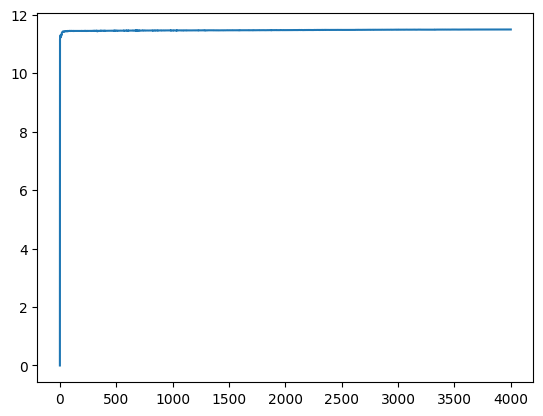

iteration 5001 loss1 is 0.01802, loss2 is 0.01281, loss3 is -0.00045, loss4 is 0.0, loss5 is 0.00243, loss6 is 0.0664, total loss 0.08685129880905151
3.3893641223764575


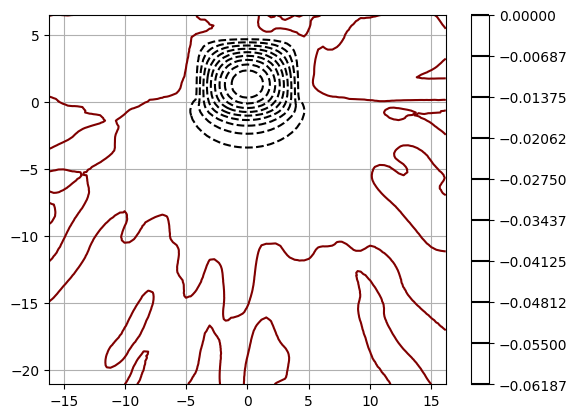

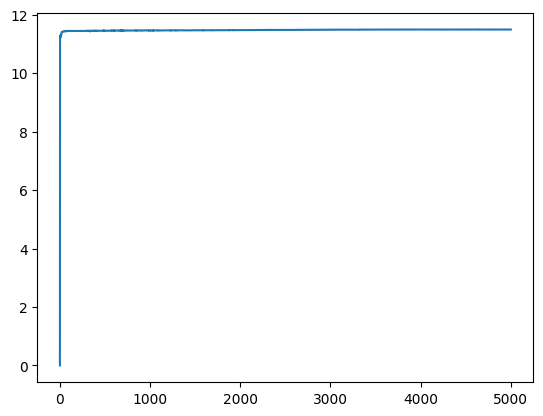

iteration 6001 loss1 is 0.0079, loss2 is 0.0081, loss3 is -0.0, loss4 is 0.0, loss5 is 0.00093, loss6 is 0.05176, total loss 0.06059247627854347
3.389522672148296


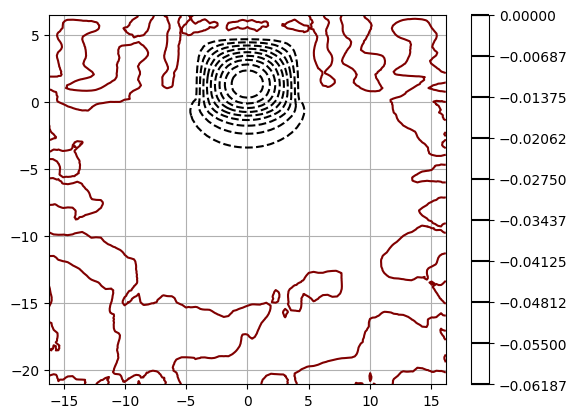

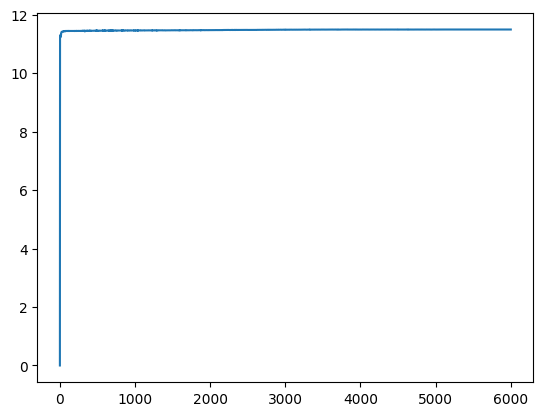

iteration 7001 loss1 is 0.00758, loss2 is 0.00717, loss3 is -0.0, loss4 is 0.0, loss5 is 0.0008, loss6 is 0.05188, total loss 0.06026400625705719
3.3894789204677056


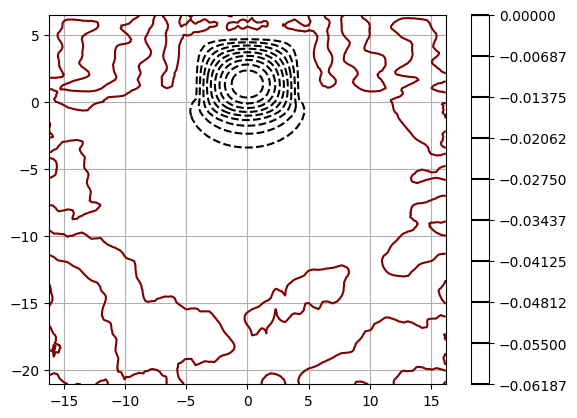

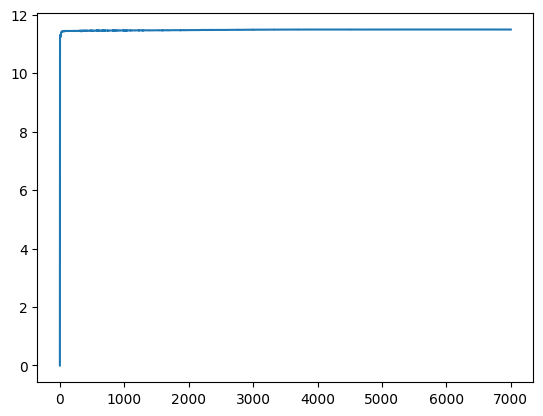

iteration 8001 loss1 is 0.00733, loss2 is 0.00668, loss3 is -0.0, loss4 is 0.0, loss5 is 0.0007, loss6 is 0.05221, total loss 0.06024615466594696
3.3894402328198545


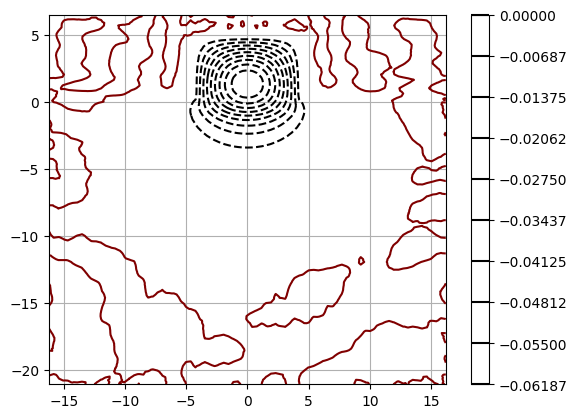

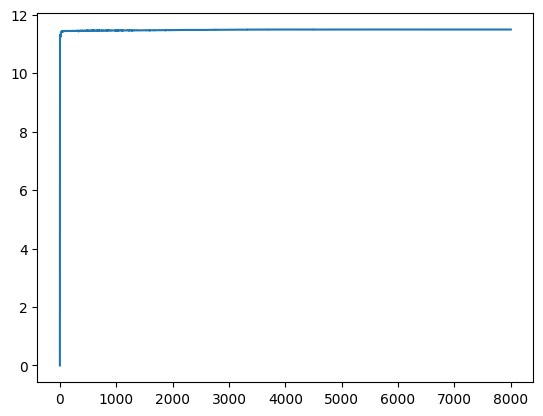

iteration 9001 loss1 is 0.00712, loss2 is 0.0065, loss3 is -2e-05, loss4 is 0.0, loss5 is 0.00065, loss6 is 0.05269, total loss 0.06046244502067566
3.3894029515777646


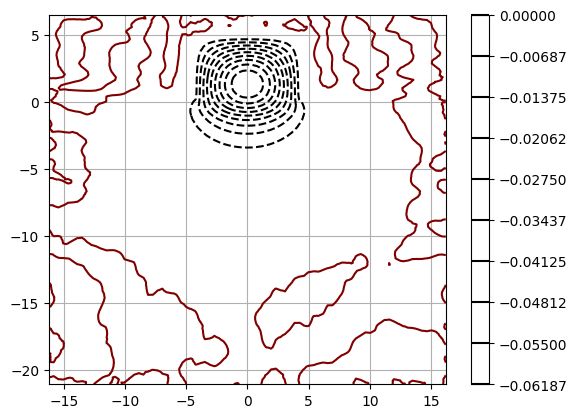

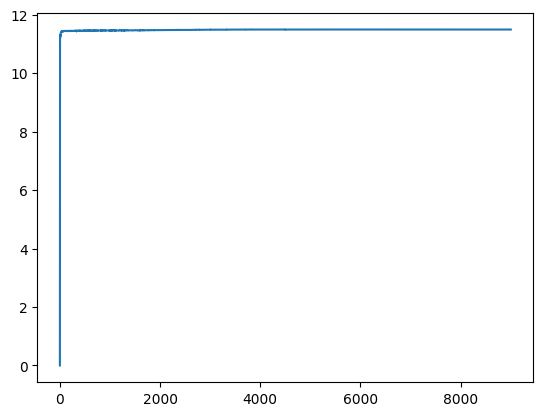

iteration 10001 loss1 is 0.00694, loss2 is 0.00626, loss3 is -0.0, loss4 is 0.0, loss5 is 0.00061, loss6 is 0.05263, total loss 0.06018334999680519
3.389380160578746


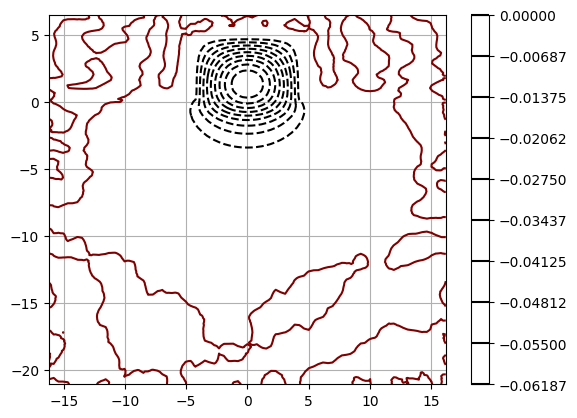

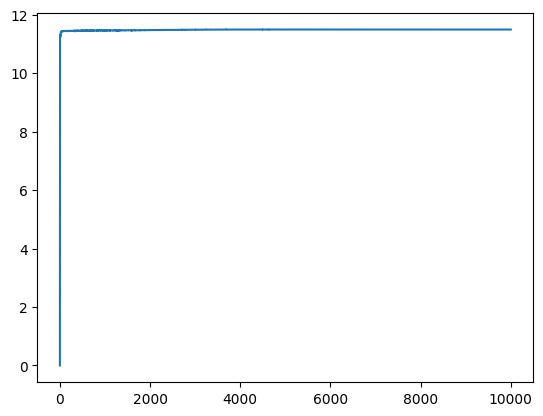

In [ ]:
loss_history, rayleigh_history, mode_errors_list = train_agent.train(10001, num_modes, weights=weights, m=m, verbose=1, calc_error=False, plot_solution=True, sample_new=False)

In [ ]:
base_model.to('cpu')

Sequential(
  (0): Linear(in_features=3, out_features=512, bias=True)
  (1): DRBF()
  (2): Linear(in_features=512, out_features=1, bias=True)
)

In [ ]:
yu = torch.arange(0, reference_device.upward_length, dy, dtype=dtype, device=memory_type).reshape(-1, 1)
end_val_yu = yu[-1]
yb = torch.arange(0, reference_device.downward_length, dy, dtype=dtype, device=memory_type).reshape(-1, 1)
end_val_yb = yb[-1]
xy = torch.cat((torch.flip(-yb, dims=(0,))[:-1], yu))

xy = torch.cat((torch.full_like(xy, 0), xy), dim=-1)
if device.augmented_input:
  xy = torch.cat((xy, torch.square(reference_device.refractive_index(xy, format='torch').view(-1, 1))), dim=-1)
u = base_model(xy.cpu()).cpu()

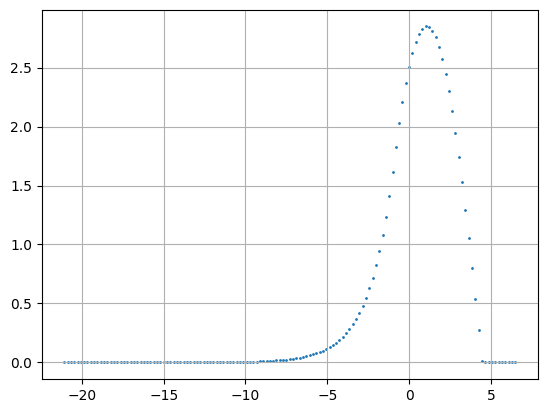

In [ ]:
plt.scatter(xy[:, 1].cpu().detach(), u[:, 0].detach().numpy(), s=1)
plt.grid()

In [ ]:
xy = torch.arange(-device.total_length_x/2, device.total_length_x/2, step=dx, device=memory_type).reshape(-1, 1)
xy = torch.cat((xy, torch.full_like(xy, 0)), dim=-1)
if device.augmented_input:
  xy = torch.cat((xy[:], torch.square(device.refractive_index(xy, format='torch').view(-1, 1))), dim=-1)
u = base_model(xy.cpu()).cpu()

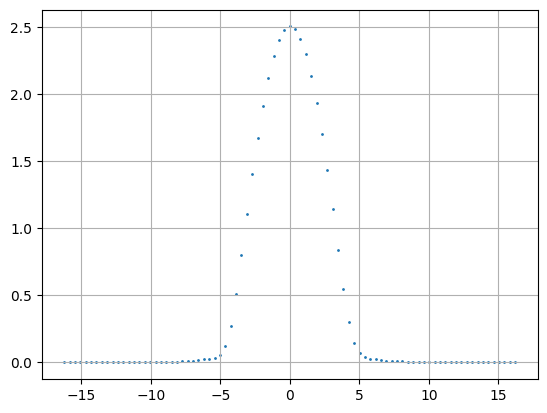

In [ ]:
plt.scatter(xy[:, 0].cpu().detach(), u[:, 0].detach().numpy(), s=1)
plt.grid()

In [ ]:
RI_squared, xy_fd, u_fd = reference_device_fd.evaluate()
xy_fd = torch.from_numpy(xy_fd).to(torch.float32)
xy = torch.cat((xy_fd, torch.square(device.refractive_index(xy_fd, format='torch'))), dim=-1)
u = base_model(xy.cpu())
u = u/torch.linalg.norm(u, dim=0, keepdims=True)
print(np.sqrt(RI_squared))

[3.39361925]


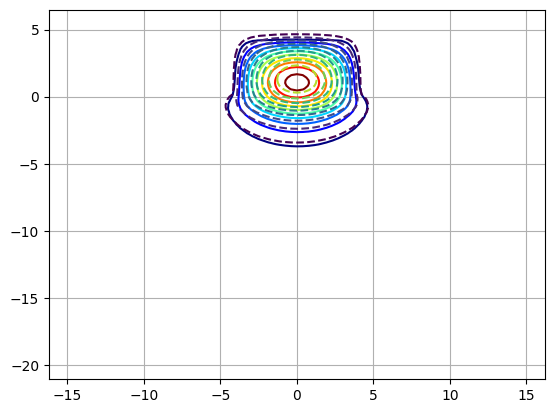

In [ ]:
levels = np.linspace(np.min(-u_fd), np.max(-u_fd), 11)[1:]
plt.tricontour(xy[:, 0].cpu().detach(), xy[:, 1].detach().cpu(), u[:,0].detach(), levels=levels, cmap='jet')
plt.tricontour(xy_fd[:, 0], xy_fd[:, 1], -u_fd[:,0], linestyles='dashed', levels=levels)
plt.grid()

# device 2

In [ ]:
# parameters
lambd = 1

# wave number and normalized spacing
k_0 = 2 * np.pi / lambd

# device 2

#spacing
dx = (0.0968/1.55) * k_0
dy =  (0.05/1.55) * k_0

# simulation lengths

core_length_x = ((3/1.55) * lambd) * k_0 # W
core_length_y = ((0.1/1.55) * lambd) * k_0 # H

substrate_length_x = ((3.05/1.55) * lambd) * k_0 # Xs
substrate_length_y = ((5.025/1.55) * lambd) * k_0 # Ys

rib_length = ((0.9/1.55) * lambd) * k_0 # D

cladding_length_y = ((0.525/1.55) * lambd) * k_0 # Yc

# refractive indices
n_core = 3.44
n_substrate = 3.36
n_cladding = 1

In [ ]:
reference_device = devices.RibWaveguide(n_substrate, n_core, n_cladding, lambd, [substrate_length_x, core_length_x, substrate_length_x], [substrate_length_y, rib_length, core_length_y, cladding_length_y], study)

In [ ]:
xy = samplers.uniform_grid_2d(reference_device, dx, dy, dtype, memory_type)
xy = xy.cpu()
boudndary_pts, boundary_vals = reference_device.get_boundaries(xy.detach().clone(), dx, dy, dtype,  memory_type)
discontinuities = reference_device.get_discontinuities(xy.detach().clone(), dx, dy)

<ipython-input-29-8c52820d3a78>:5: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(boudndary_pts[:, 0], boudndary_pts[:, 1], marker='x', s=4, c='black', cmap=cm);
<ipython-input-29-8c52820d3a78>:10: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(discontinuity[:, 0].detach(), discontinuity[:, 1].detach(), s=1/2, marker='x', c='orange', cmap=cm);


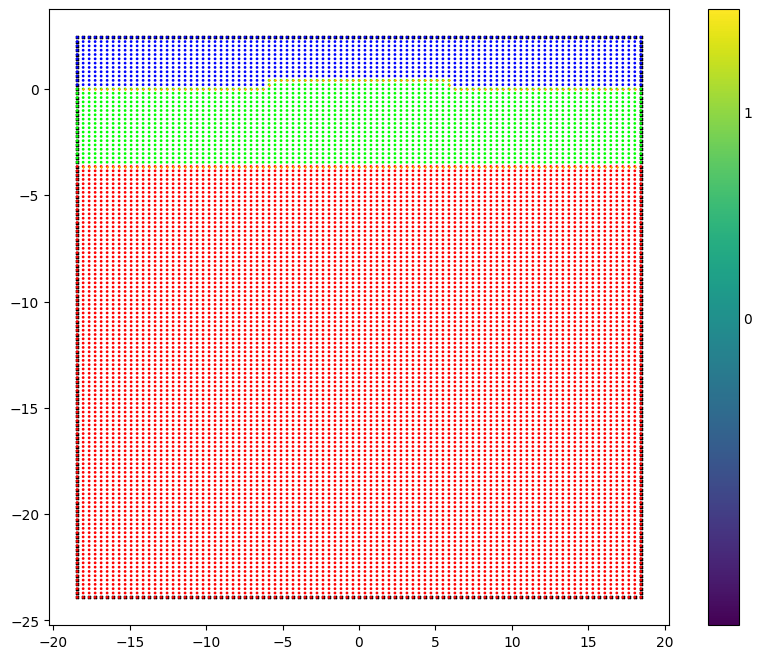

In [ ]:
plt.figure(figsize=(10, 8))

from_list = matplotlib.colors.LinearSegmentedColormap.from_list
cm = from_list(None, [(1, 0, 0), (0, 1, 0), (0, 0, 1)], 3)
plt.scatter(boudndary_pts[:, 0], boudndary_pts[:, 1], marker='x', s=4, c='black', cmap=cm);

plt.scatter(xy[:, 0], xy[:, 1], s=1, c=reference_device.regions(xy, format='torch'), cmap=cm);

for discontinuity in discontinuities:
  plt.scatter(discontinuity[:, 0].detach(), discontinuity[:, 1].detach(), s=1/2, marker='x', c='orange', cmap=cm);

# len_rib = guide.lengths_y[1]
# len_rib = ((guide.lengths_y[1])//dy)*dy

# plt.axhline(y=-len_rib, color='black', linestyle='dashed')
plt.clim(-1.5, 1.5)
cb = plt.colorbar(ticks=[0, 1])
cb.ax.tick_params(length=0)

In [ ]:
torch.manual_seed(42)
# base_model = models.discontinuity_capturing_network(2, 256, num_modes, 1, 'RBF')
base_model = models.discontinuity_capturing_network(2, 512, num_modes, 1, 'DRBF')
optimizer = torch.optim.Adamax(base_model.parameters(), lr=1e-2)
# optimizer = torch.optim.LBFGS(base_model.parameters(),
#                               lr=float(5e-1),
#                               max_iter=5000,
#                               max_eval=5000,
#                               history_size=300,
#                               line_search_fn="strong_wolfe",
#                               tolerance_change=10.0 * np.finfo(float).eps)
# scheduler = torch.optim.lr_scheduler.MultiStepLR(optimzer, milestones=[1000, 2000, 3000], gamma=0.2)
scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=[9000], gamma=1e-2)
print('number of trainable parameters', sum([p.numel() for p in base_model.parameters() if p.requires_grad]))

number of trainable parameters 3073


In [ ]:
device = devices.RibWaveguideWithPINNs(n_substrate, n_core, n_cladding, lambd, [substrate_length_x, core_length_x, substrate_length_x], [substrate_length_y, rib_length, core_length_y, cladding_length_y], study, base_model, True)

In [ ]:
reference_device_fd = devices.RibWaveguideWithFD(n_substrate, n_core, n_cladding, lambd, [substrate_length_x, core_length_x, substrate_length_x], [substrate_length_y, rib_length, core_length_y, cladding_length_y], study, dx, dy)

In [ ]:
base_model.to(memory_type)
dummy_optim = torch.optim.Adamax(base_model.parameters(), lr=1e-2)
xy_dummy = torch.rand(1000, 3).to(memory_type)*10-5
example_fun = torch.exp(-(xy_dummy[:, 0]**2+xy_dummy[:, 1]**2)/10)*5
example_fun = example_fun.unsqueeze(1)
for i in range(1000):
  optimizer.zero_grad()
  u = base_model(xy_dummy)
  loss = torch.mean((u-example_fun)**2)
  base_model.zero_grad()
  loss.backward()
  optimizer.step()
dummy_optim.zero_grad()
print(loss.item())

2.632291398185771e-05


In [ ]:
train_agent = trainers.Trainer2D(dtype, device, reference_device_fd, memory_type, samplers.uniform_grid_2d, optimizer, scheduler, dx=dx, dy=dy, num_samples=None, n_lower=None, n_upper=None)

num samples 12445


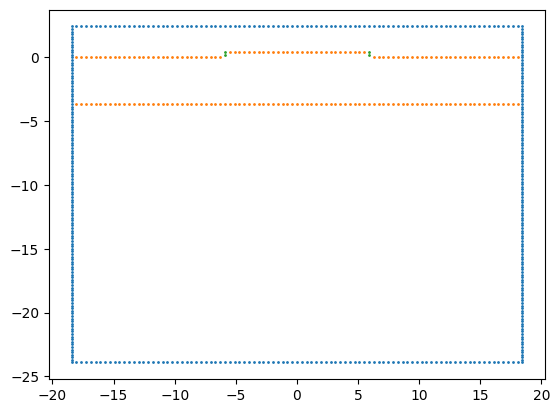

iteration 1 loss1 is 1.21637, loss2 is 0.58993, loss3 is 38.15992, loss4 is 0.0, loss5 is 0.26876, loss6 is 0.47127, total loss 1.9564071893692017
2.695535667136756


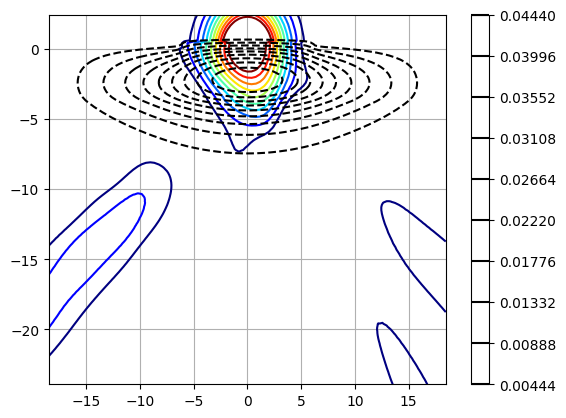

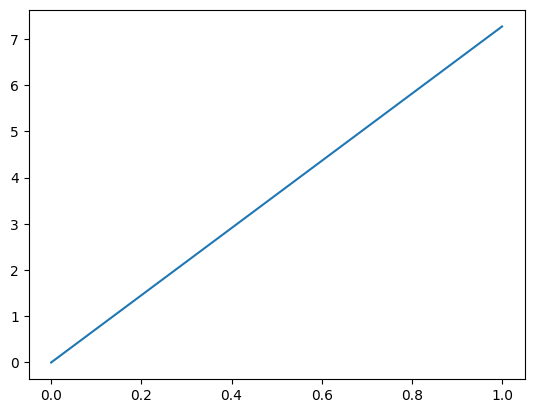

iteration 1001 loss1 is 0.03295, loss2 is 0.01016, loss3 is -0.0011, loss4 is 0.0, loss5 is 0.00873, loss6 is 0.05643, total loss 0.09811083972454071
3.392945791821649


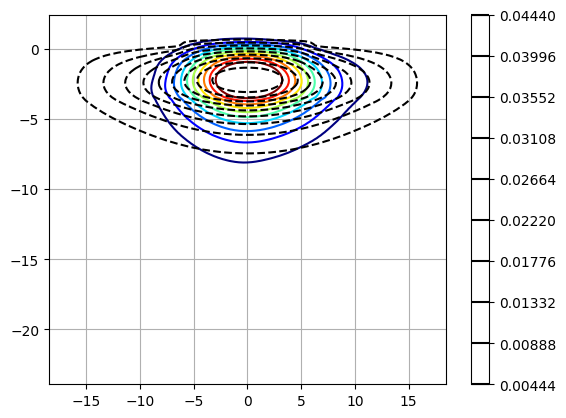

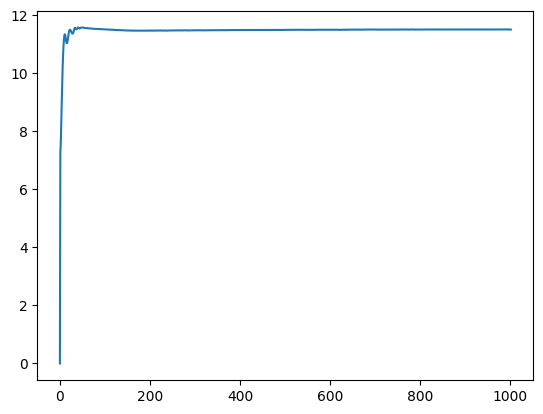

iteration 2001 loss1 is 0.02175, loss2 is 0.00844, loss3 is -0.00384, loss4 is 0.0, loss5 is 0.00587, loss6 is 0.04461, total loss 0.07222992181777954
3.394204215043339


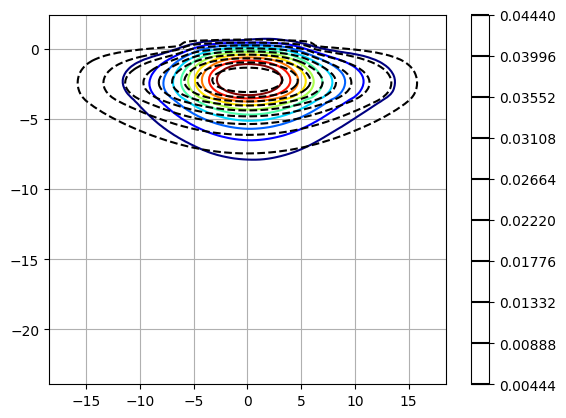

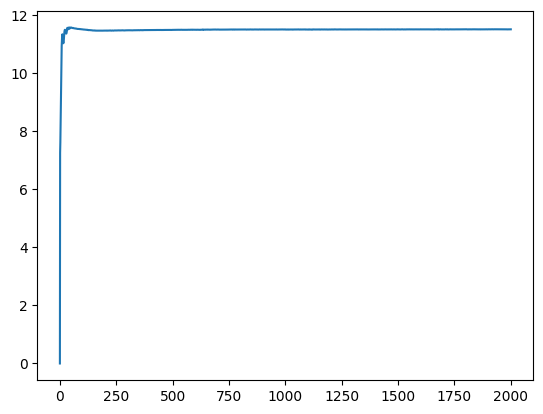

iteration 3001 loss1 is 0.01954, loss2 is 0.00613, loss3 is -0.00079, loss4 is 0.0, loss5 is 0.00558, loss6 is 0.03317, total loss 0.058296844363212585
3.3944624179406557


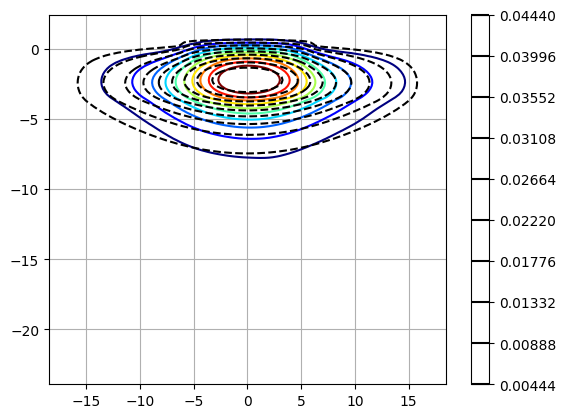

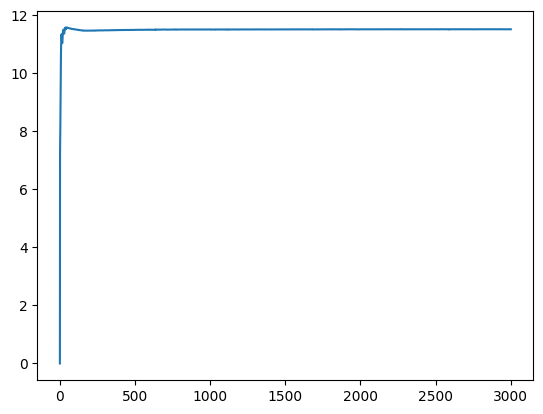

iteration 4001 loss1 is 0.01698, loss2 is 0.00554, loss3 is -0.00052, loss4 is 0.0, loss5 is 0.00388, loss6 is 0.03488, total loss 0.05573025345802307
3.3949074136190958


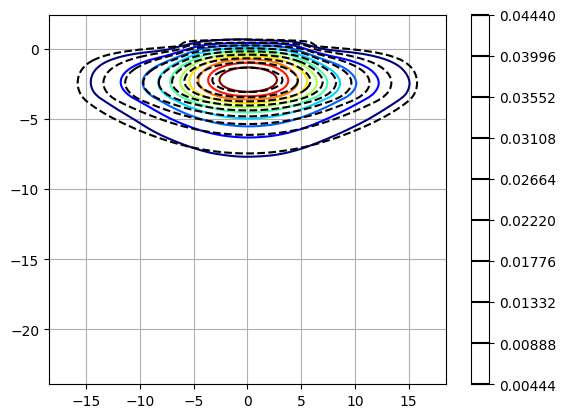

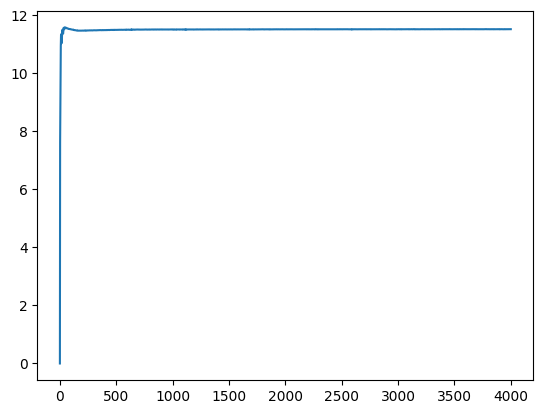

iteration 5001 loss1 is 0.01572, loss2 is 0.00443, loss3 is -0.00179, loss4 is 0.0, loss5 is 0.00454, loss6 is 0.0403, total loss 0.060558632016181946
3.3948078284279313


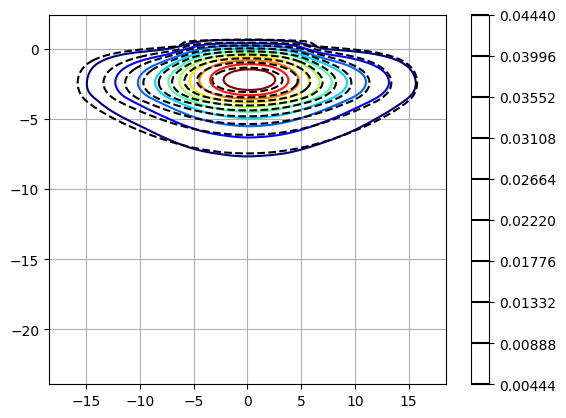

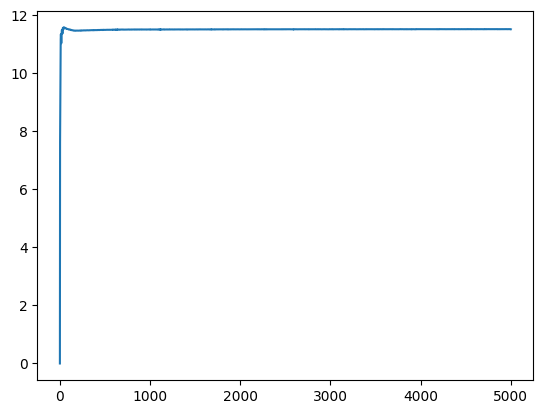

iteration 6001 loss1 is 0.01592, loss2 is 0.00371, loss3 is -0.00098, loss4 is 0.0, loss5 is 0.00351, loss6 is 0.03271, total loss 0.05213569104671478
3.3951223054184663


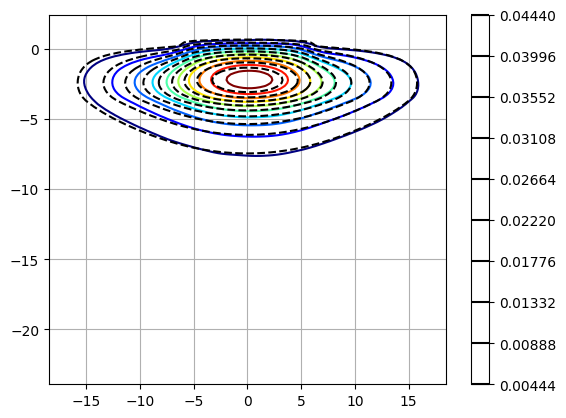

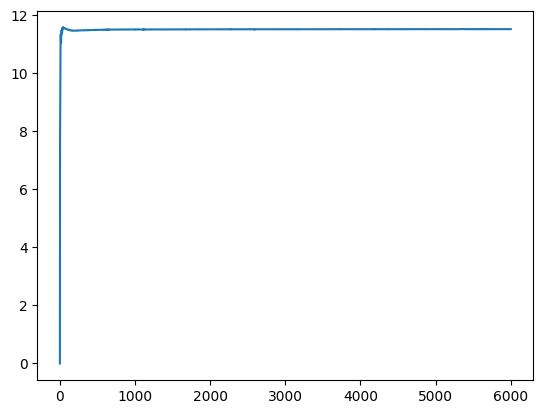

iteration 7001 loss1 is 0.01391, loss2 is 0.00293, loss3 is -0.0009, loss4 is 0.0, loss5 is 0.00355, loss6 is 0.03197, total loss 0.049437783658504486
3.3951561531482253


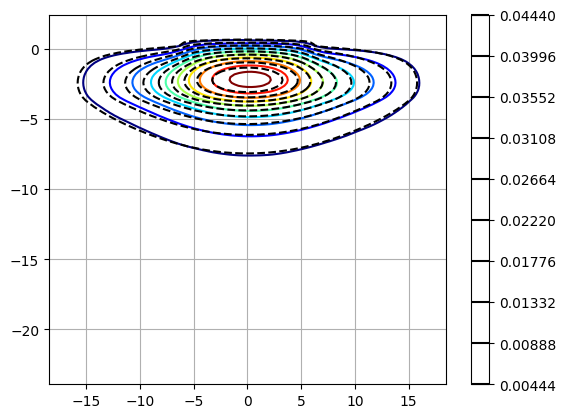

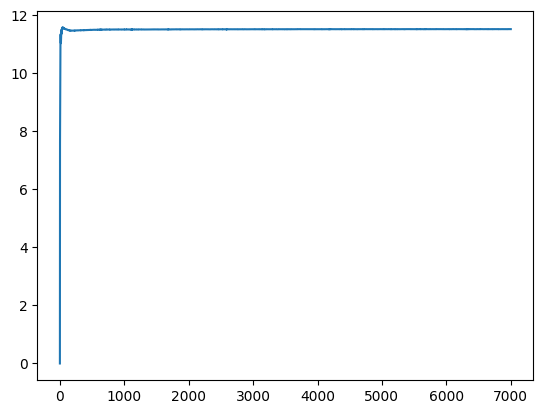

iteration 8001 loss1 is 0.01339, loss2 is 0.00325, loss3 is -0.00058, loss4 is 0.0, loss5 is 0.00388, loss6 is 0.03328, total loss 0.05054866150021553
3.395260503153969


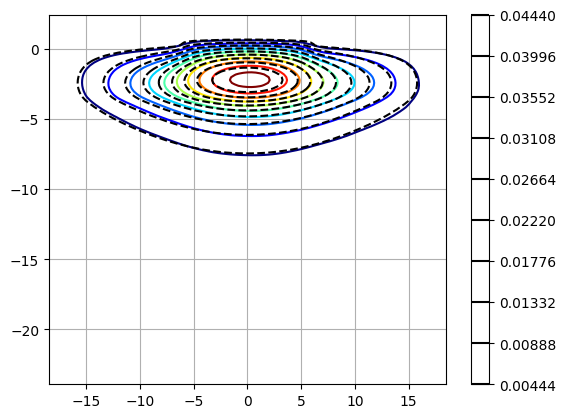

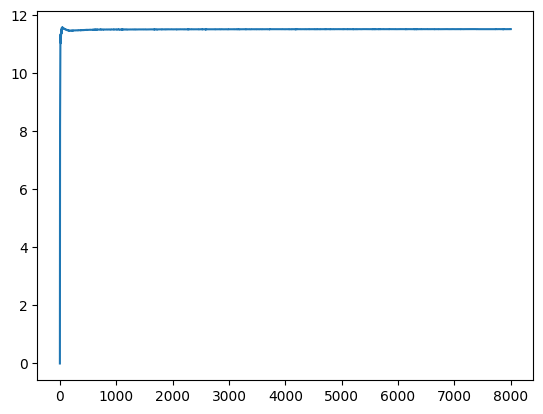

iteration 9001 loss1 is 0.01543, loss2 is 0.00241, loss3 is -0.00098, loss4 is 0.0, loss5 is 0.00295, loss6 is 0.02736, total loss 0.045741453766822815
3.3951777818112823


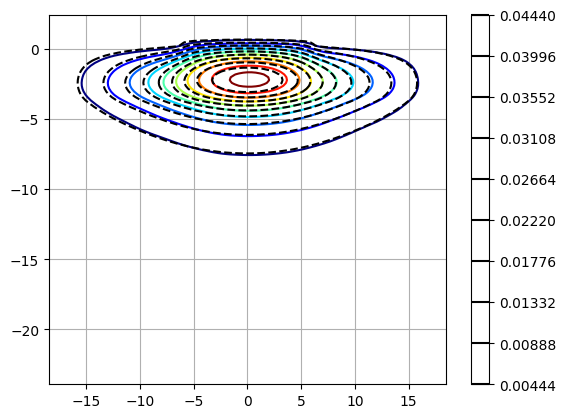

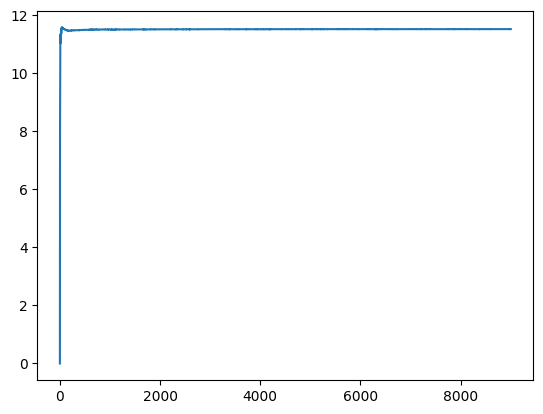

iteration 10001 loss1 is 0.00508, loss2 is 0.00152, loss3 is -0.0, loss4 is 0.0, loss5 is 0.00129, loss6 is 0.00248, total loss 0.008855292573571205
3.3952602222699677


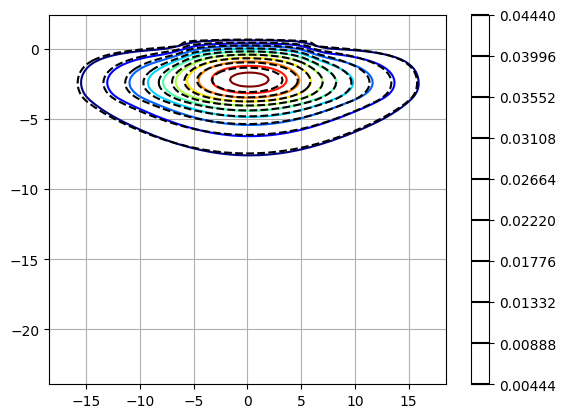

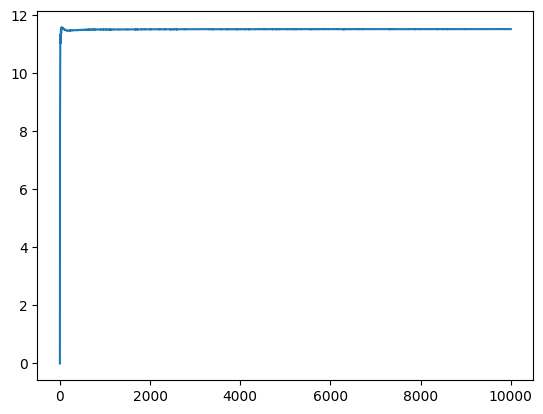

In [ ]:
loss_history, rayleigh_history, mode_errors_list = train_agent.train(10001, num_modes, weights=weights, m=m, verbose=1, calc_error=False, plot_solution=True, sample_new=False)

In [ ]:
base_model.to('cpu')

Sequential(
  (0): Linear(in_features=3, out_features=512, bias=True)
  (1): DRBF()
  (2): Linear(in_features=512, out_features=1, bias=True)
)

In [ ]:
yu = torch.arange(0, reference_device.upward_length, dy, dtype=dtype, device=memory_type).reshape(-1, 1)
end_val_yu = yu[-1]
yb = torch.arange(0, reference_device.downward_length, dy, dtype=dtype, device=memory_type).reshape(-1, 1)
end_val_yb = yb[-1]
xy = torch.cat((torch.flip(-yb, dims=(0,))[:-1], yu))

xy = torch.cat((torch.full_like(xy, dx), xy), dim=-1)
if device.augmented_input:
  xy = torch.cat((xy, torch.square(reference_device.refractive_index(xy, format='torch').view(-1, 1))), dim=-1)
u = base_model(xy.cpu()).cpu()

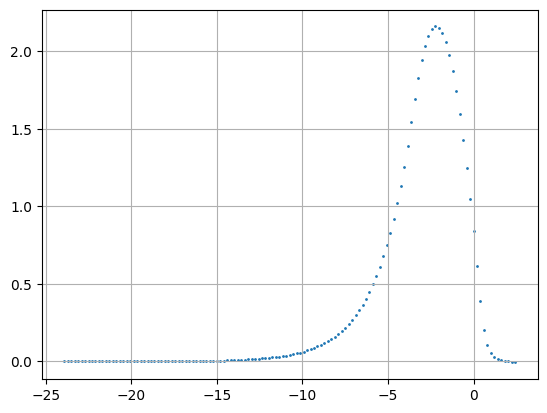

In [ ]:
plt.scatter(xy[:, 1].cpu().detach(), u[:, 0].detach().numpy(), s=1)
plt.grid()

In [ ]:
xy = torch.arange(-device.total_length_x/2, device.total_length_x/2, step=dx/2, device=memory_type).reshape(-1, 1)
xy = torch.cat((xy, torch.full_like(xy, 0)), dim=-1)
if device.augmented_input:
  xy = torch.cat((xy[:], torch.square(device.refractive_index(xy, format='torch').view(-1, 1))), dim=-1)
u = base_model(xy.cpu()).cpu()

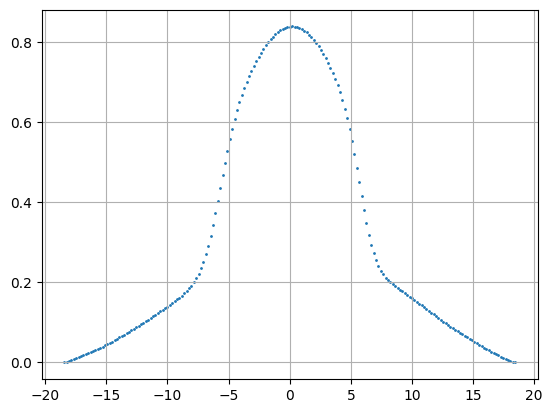

In [ ]:
plt.scatter(xy[:, 0].cpu().detach(), u[:, 0].detach().numpy(), s=1)
plt.grid()

In [ ]:
RI_squared, xy_fd, u_fd = reference_device_fd.evaluate()
xy_fd = torch.from_numpy(xy_fd).to(torch.float32)
xy = torch.cat((xy_fd, torch.square(device.refractive_index(xy_fd, format='torch'))), dim=-1)
u = base_model(xy.cpu())
u = u/torch.linalg.norm(u, dim=0, keepdims=True)
print(np.sqrt(RI_squared))

[3.39824864]


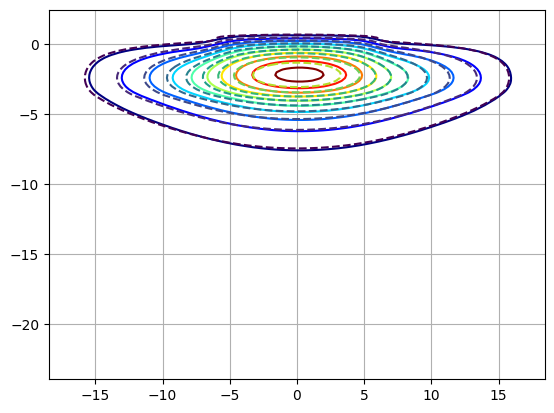

In [ ]:
levels = np.linspace(np.min(u_fd), np.max(u_fd), 11)[1:]
plt.tricontour(xy[:, 0].cpu().detach(), xy[:, 1].detach().cpu(), u[:,0].detach(), levels=levels, cmap='jet')
plt.tricontour(xy_fd[:, 0], xy_fd[:, 1], u_fd[:,0], linestyles='dashed', levels=levels)
plt.grid()

# device 3

In [ ]:
# parameters
lambd = 1

# wave number and normalized spacing
k_0 = 2 * np.pi / lambd

# device 3 is done for both scalar and TM
# device 3
#spacing
dx = (0.0976/1.55) * k_0
dy =  (0.1/1.55) * k_0

# simulation lengths

core_length_x = ((4/1.55) * lambd) * k_0 # W
core_length_y = ((2.5/1.55) * lambd) * k_0 # H

substrate_length_x = ((4.34/1.55) * lambd) * k_0 # Xs
substrate_length_y = ((7.550/1.55) * lambd) * k_0 # Ys

rib_length = ((3.5/1.55) * lambd) * k_0 # D

cladding_length_y = ((0.55/1.55) * lambd) * k_0 # Yc

# refractive indices
n_core = 3.44
n_substrate = 3.435
n_cladding = 1

In [ ]:
reference_device = devices.RibWaveguide(n_substrate, n_core, n_cladding, lambd, [substrate_length_x, core_length_x, substrate_length_x], [substrate_length_y, rib_length, core_length_y, cladding_length_y], study)

In [ ]:
xy = samplers.uniform_grid_2d(reference_device, dx, dy, dtype, memory_type)
xy = xy.cpu()
boudndary_pts, boundary_vals = reference_device.get_boundaries(xy.detach().clone(), dx, dy, dtype,  memory_type)
discontinuities = reference_device.get_discontinuities(xy.detach().clone(), dx, dy)

<ipython-input-44-8c52820d3a78>:5: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(boudndary_pts[:, 0], boudndary_pts[:, 1], marker='x', s=4, c='black', cmap=cm);
<ipython-input-44-8c52820d3a78>:10: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(discontinuity[:, 0].detach(), discontinuity[:, 1].detach(), s=1/2, marker='x', c='orange', cmap=cm);


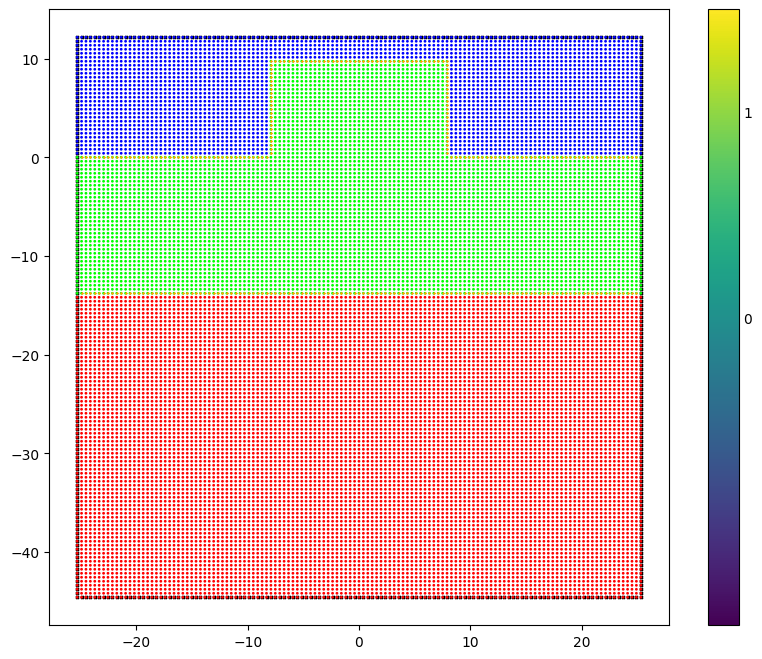

In [ ]:
plt.figure(figsize=(10, 8))

from_list = matplotlib.colors.LinearSegmentedColormap.from_list
cm = from_list(None, [(1, 0, 0), (0, 1, 0), (0, 0, 1)], 3)
plt.scatter(boudndary_pts[:, 0], boudndary_pts[:, 1], marker='x', s=4, c='black', cmap=cm);

plt.scatter(xy[:, 0], xy[:, 1], s=1, c=reference_device.regions(xy, format='torch'), cmap=cm);

for discontinuity in discontinuities:
  plt.scatter(discontinuity[:, 0].detach(), discontinuity[:, 1].detach(), s=1/2, marker='x', c='orange', cmap=cm);

# len_rib = guide.lengths_y[1]
# len_rib = ((guide.lengths_y[1])//dy)*dy

# plt.axhline(y=-len_rib, color='black', linestyle='dashed')
plt.clim(-1.5, 1.5)
cb = plt.colorbar(ticks=[0, 1])
cb.ax.tick_params(length=0)

In [ ]:
torch.manual_seed(42)
# base_model = models.discontinuity_capturing_network(2, 256, num_modes, 1, 'RBF')
base_model = models.discontinuity_capturing_network(2, 64, num_modes, 2, 'DRBF')
optimizer = torch.optim.Adamax(base_model.parameters(), lr=1e-2)
# optimizer = torch.optim.LBFGS(base_model.parameters(),
#                               lr=float(5e-1),
#                               max_iter=5000,
#                               max_eval=5000,
#                               history_size=300,
#                               line_search_fn="strong_wolfe",
#                               tolerance_change=10.0 * np.finfo(float).eps)
# scheduler = torch.optim.lr_scheduler.MultiStepLR(optimzer, milestones=[1000, 2000, 3000], gamma=0.2)
scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=[5000], gamma=1e-2)
print('number of trainable parameters', sum([p.numel() for p in base_model.parameters() if p.requires_grad]))

number of trainable parameters 4609


In [ ]:
device = devices.RibWaveguideWithPINNs(n_substrate, n_core, n_cladding, lambd, [substrate_length_x, core_length_x, substrate_length_x], [substrate_length_y, rib_length, core_length_y, cladding_length_y], study, base_model, True)

In [ ]:
reference_device_fd = devices.RibWaveguideWithFD(n_substrate, n_core, n_cladding, lambd, [substrate_length_x, core_length_x, substrate_length_x], [substrate_length_y, rib_length, core_length_y, cladding_length_y], study, dx, dy)

In [ ]:
base_model.to(memory_type)
dummy_optim = torch.optim.Adamax(base_model.parameters(), lr=1e-2)
xy_dummy = torch.rand(1000, 3).to(memory_type)*10-5
example_fun = torch.exp(-(xy_dummy[:, 0]**2+xy_dummy[:, 1]**2)/10)*5
example_fun = example_fun.unsqueeze(1)
for i in range(1000):
  optimizer.zero_grad()
  u = base_model(xy_dummy)
  loss = torch.mean((u-example_fun)**2)
  base_model.zero_grad()
  loss.backward()
  optimizer.step()
dummy_optim.zero_grad()
print(loss.item())

8.33144222269766e-05


In [ ]:
train_agent = trainers.Trainer2D(dtype, device, reference_device_fd, memory_type, samplers.uniform_grid_2d, optimizer, scheduler, dx=dx, dy=dy, num_samples=None, n_lower=None, n_upper=None)

num samples 18189


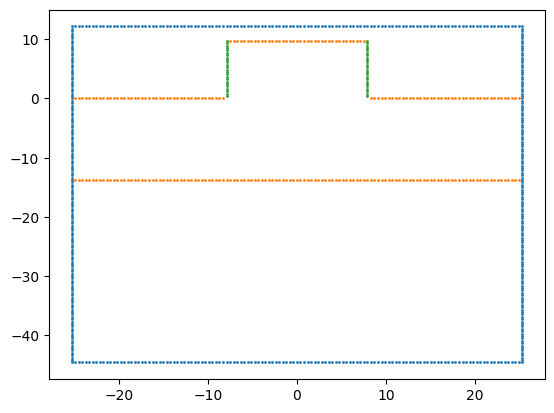

iteration 1 loss1 is 1.76397, loss2 is 0.58348, loss3 is 20.6259, loss4 is 0.0, loss5 is 0.62323, loss6 is 0.54937, total loss 2.9365668296813965
3.1844741820817477


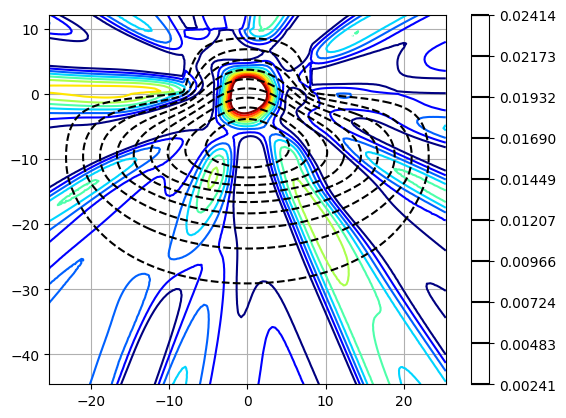

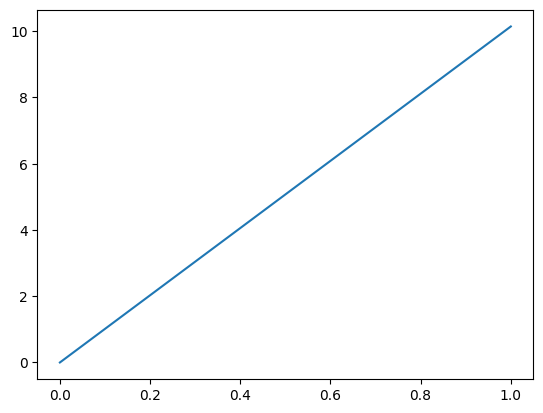

iteration 251 loss1 is 0.02485, loss2 is 0.969, loss3 is 0.99996, loss4 is 0.0, loss5 is 0.08402, loss6 is 0.02613, total loss 0.13499322533607483
3.4351897365802304


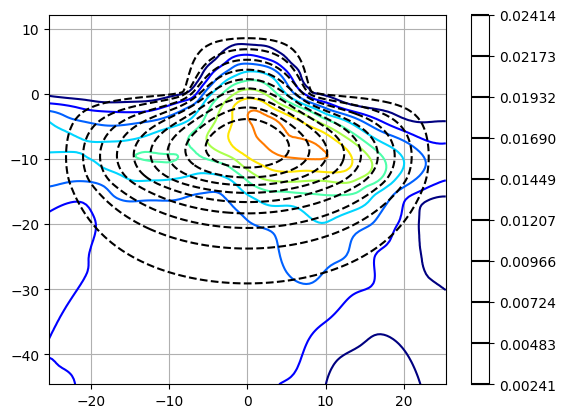

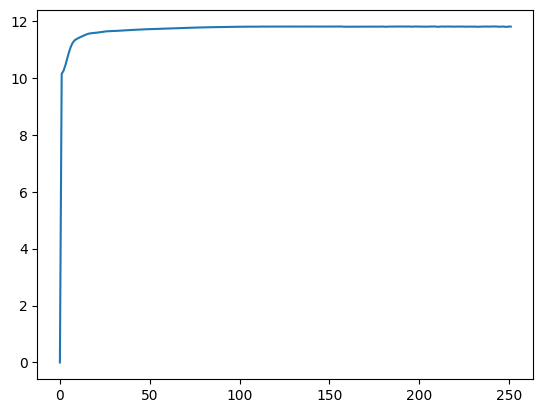

iteration 501 loss1 is 0.02229, loss2 is 0.98509, loss3 is 1.04023, loss4 is 0.0, loss5 is 0.04673, loss6 is 0.01645, total loss 0.08547364175319672
3.4345050596232403


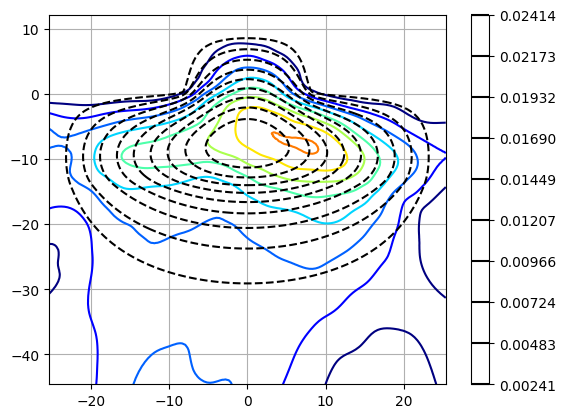

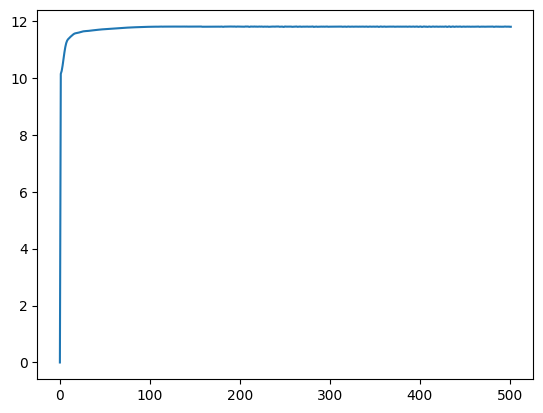

iteration 751 loss1 is 0.02071, loss2 is 0.99173, loss3 is 1.13574, loss4 is 0.0, loss5 is 0.03246, loss6 is 0.01687, total loss 0.0700424313545227
3.433329879117049


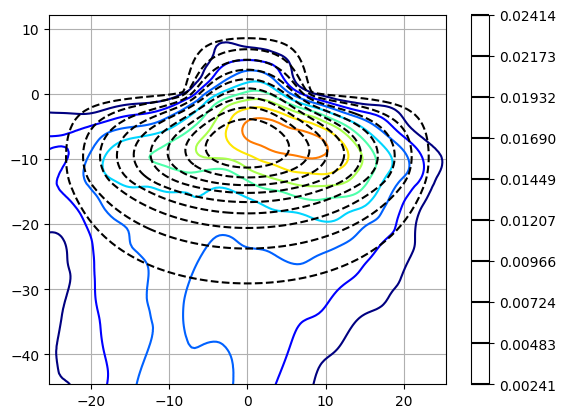

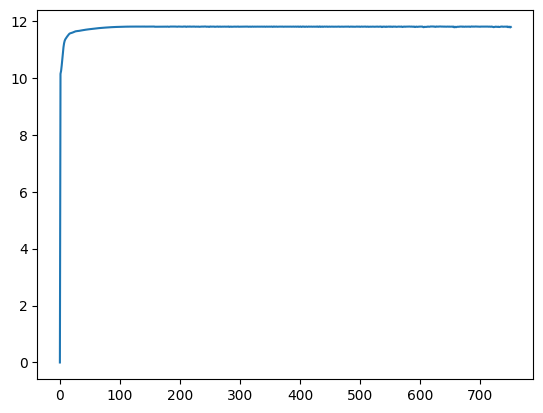

iteration 1001 loss1 is 0.01661, loss2 is 0.99047, loss3 is 1.01757, loss4 is 0.0, loss5 is 0.03354, loss6 is 0.00615, total loss 0.05630334094166756
3.434783833460991


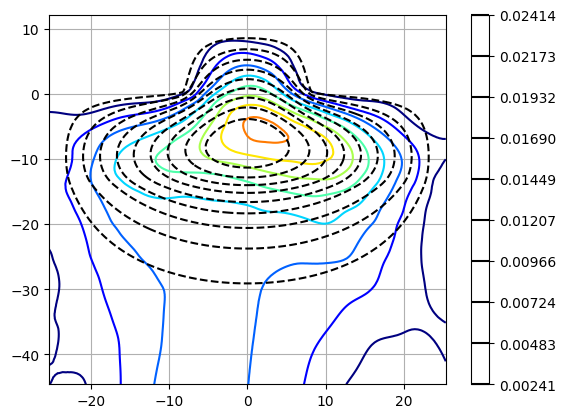

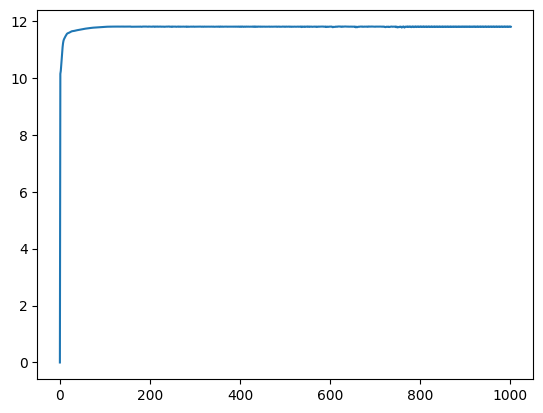

iteration 1251 loss1 is 0.01081, loss2 is 0.99552, loss3 is 1.01746, loss4 is 0.0, loss5 is 0.01542, loss6 is 0.0042, total loss 0.03042908012866974
3.434785221720296


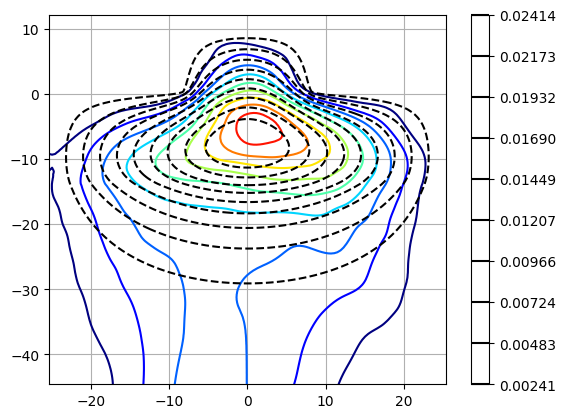

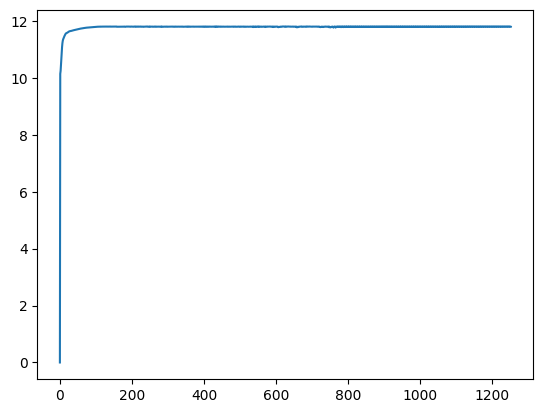

In [ ]:
loss_history, rayleigh_history, mode_errors_list = train_agent.train(10001, num_modes, weights=weights, m=m, verbose=4, calc_error=False, plot_solution=True, sample_new=False)

In [ ]:
base_model.to('cpu')

In [ ]:
yu = torch.arange(0, reference_device.upward_length, dy/2, dtype=dtype, device=memory_type).reshape(-1, 1)
end_val_yu = yu[-1]
yb = torch.arange(0, reference_device.downward_length, dy/2, dtype=dtype, device=memory_type).reshape(-1, 1)
end_val_yb = yb[-1]
xy = torch.cat((torch.flip(-yb, dims=(0,))[:-1], yu))

xy = torch.cat((torch.full_like(xy, dx), xy), dim=-1)
if device.augmented_input:
  xy = torch.cat((xy, torch.square(reference_device.refractive_index(xy, format='torch').view(-1, 1))), dim=-1)
u = base_model(xy.cpu()).cpu()

In [ ]:
plt.scatter(xy[:, 1].cpu().detach(), u[:, 0].detach().numpy(), s=1)
plt.grid()

In [ ]:
xy = torch.arange(-device.total_length_x/2, device.total_length_x/2, step=dx/2, device=memory_type).reshape(-1, 1)
xy = torch.cat((xy, torch.full_like(xy, 0)), dim=-1)
if device.augmented_input:
  xy = torch.cat((xy[:], torch.square(device.refractive_index(xy, format='torch').view(-1, 1))), dim=-1)
u = base_model(xy.cpu()).cpu()

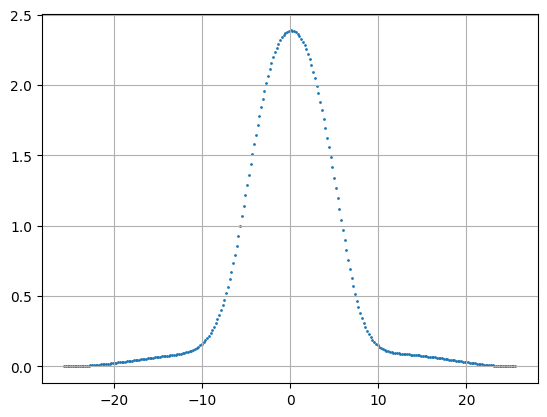

In [ ]:
plt.scatter(xy[:, 0].cpu().detach(), u[:, 0].detach().numpy(), s=1)
plt.grid()

In [ ]:
RI_squared, xy_fd, u_fd = reference_device_fd.evaluate()
xy_fd = torch.from_numpy(xy_fd).to(torch.float32)
xy = torch.cat((xy_fd, torch.square(device.refractive_index(xy_fd, format='torch'))), dim=-1)
u = base_model(xy.cpu())
u = u/torch.linalg.norm(u, dim=0, keepdims=True)
print(np.sqrt(RI_squared))

[3.43672315]


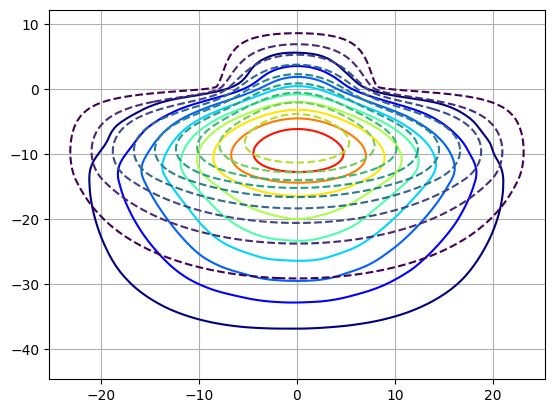

In [ ]:
levels = np.linspace(np.min(u_fd), np.max(u_fd), 11)[1:]
plt.tricontour(xy[:, 0].cpu().detach(), xy[:, 1].detach().cpu(), u[:,0].detach(), levels=levels, cmap='jet')
plt.tricontour(xy_fd[:, 0], xy_fd[:, 1], u_fd[:,0], linestyles='dashed', levels=levels)
plt.grid()